# Lava Benchmark

Most of the setup is already done for you, but a few values are left to input.

In [4]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import subprocess
import os
import utm
import xarray as xr
import rasterio as rio
from pyproj import Transformer
import sys
import glob
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

### Common Parameter

Below, please enter the common parameters that all of the models will ingest. This workflow expects a lat/long or UTM referenced GeoTIFF.

In [23]:
easting = 234500

northing = 2160119

# Total volume in m^3 from eruption
volume = 2.5e8

# Name to reference files
name = "MaunaLoa"

# IMEX and Lava2d are depth-averaged time-dependent models, and thus require an approximate run time.
# Below, we assign a reasonable yet arbitrary time (3 hour) for the flow to run (in seconds)
# Please change it at your leisure
run_time = 3600

# Please enter 1, 2, or 4 (original resolution, half, quarter respectively)
downscale = 2

dem = "hawaii.tif"

### The next two cells format and set up for a clean execution.

In [24]:
raster = rxr.open_rasterio(dem)
raster = raster.sel({"band": 1})
output_num = str(int(run_time/100))
out = output_num.zfill(4)

filename, file_extension = os.path.splitext(dem)
file_name = os.path.basename(dem)
file_name = os.path.splitext(file_name)[0]
type_flag = 0 #0 is ascii, 1 is tiff
if file_extension in [".geotiff", ".tiff", ".tif"]:
    type_flag = 1
    asc_name = "".join((name,".asc"))
    tiff_name = "".join((name, ".tiff"))
    victor.tiff_to_utm_ascii(dem,asc_name)
    victor.convert_dem_format(dem,tiff_name, output_format="geotiff")
elif file_extension in [".asc", ".ascii"]:
    type_flag = 0
    tiff_name = "".join((file_name, ".tiff"))
    raster.rio.to_raster(tiff_name)

Opening hawaii.tif...
Automatically determined UTM zone: 5
Using UTM zone 5 north (CRS: EPSG:32605)
Reprojecting to UTM...
Converting to ASCII format: MaunaLoa.asc
Conversion complete. ASCII file saved to: MaunaLoa.asc


### Before we jump into the computation, we confirm the location of the vent we want to use.

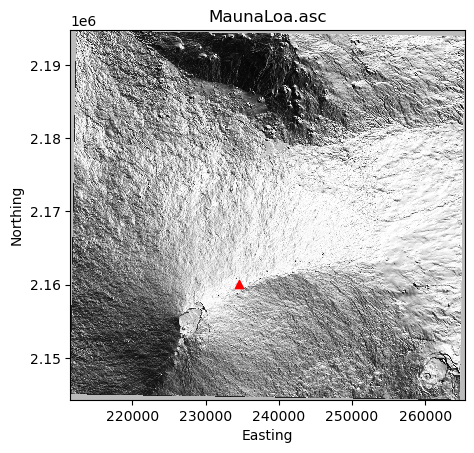

In [33]:
rstr = rio.open(asc_name)
bounds = rstr.bounds
crs = rstr.crs
res = rstr.res
transformer = Transformer.from_crs(crs.to_string(), "EPSG:4326")
transformer2 = Transformer.from_crs("EPSG:4326", crs.to_string())
xll, yll = int(bounds.left), int(bounds.bottom)
r = rio.open(dem)
array = rxr.open_rasterio(asc_name)

vent_easting, vent_northing = easting, northing
coordinates = np.array([easting, northing])
victor.plot_dem(asc_name, coordinates)

### Now, we can run everything. Press run on every cell until the next text box.

Keep in mind, the time dependent models can take a long time, so sit back and relax, though keep an eye out for your results. Each model will also display its individual result before the final comparison.

### Molasses: Additional Notes

Molasses input parameters are stored in `custom_molasses.conf` in the `Molasses` folder. The most impactful change would be that of changing the minimum and maximum residual, as the cellular automata structure will cause a much larger or smaller area to be impacted. As a stochastic model, no physical parameters are used.

In [28]:
os.chdir("/home/jovyan/Lava Benchmark/Molasses")
f = open("custom_molasses.conf","r+")
conf = f.readlines()
conf[2] = "MIN_RESIDUAL = 1\n"
conf[3] = "MAX_RESIDUAL = 20\n"
conf[4] = f"""MIN_TOTAL_VOLUME = {str(volume)}\n"""
conf[5] = f"""MAX_TOTAL_VOLUME = {str(volume)}\n"""
conf[6] = f"""MIN_PULSE_VOLUME = {float(volume)/1000}\n"""
conf[7] = f"""MAX_PULSE_VOLUME = {float(volume)/1000}\n"""
conf[10] = f"""DEM_FILE = {asc_name}\n"""
f.seek(0)
f.writelines(conf)
f.truncate()
f.close()

f=open("events.in","w")
f.write(f"""{easting},{northing}""")
f.close()
# if not os.path.exists(f"../{asc_name}"):
subprocess.run(f"""ln -s ../{asc_name} .""",shell=True)
subprocess.run("molasses custom_molasses.conf",shell=True, stderr=subprocess.DEVNULL)

victor.convert_molasses(f"molasses_{name}", resolution=res)
os.chdir("/home/jovyan/Lava Benchmark")

Seeding random number generator: 1754681323


               MOLASSES is a lava flow simulator.

Config file: custom_molasses.conf
Reading in Parameters...
             PARENTS = 1                    [assigned]
    ELEVATION_UNCERT = 0                    [assigned]
        MIN_RESIDUAL = .1                   [assigned]
        MAX_RESIDUAL = 2                    [assigned]
    MIN_TOTAL_VOLUME = 250000000.0          [assigned]
    MAX_TOTAL_VOLUME = 250000000.0          [assigned]
    MIN_PULSE_VOLUME = 250000.0             [assigned]
    MAX_PULSE_VOLUME = 250000.0             [assigned]
                RUNS = 1                    [assigned]
      ASCII_FLOW_MAP = 1                    [assigned]
            DEM_FILE = MaunaLoa.asc         [assigned]
[assigned]VENTS_FILE = events.in            
Nothing missing.

DEM Information [Arc/Info ASCII Grid]:
  File:              MaunaLoa.asc
  Lower Left Origin: (211517.558986,2144279.449564)
  GMT Range Code:    -R211517.559/265377.311/214427

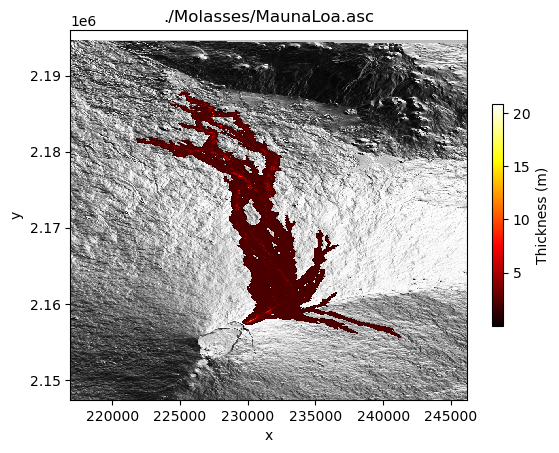

In [11]:
victor.plot_flow("./Molasses/MaunaLoa.asc",f"./Molasses/molasses_{name}.asc")

### MrLavaLoba: Additional Notes

MrLavaLoba input parameters are stored in `input_data.py` in the `mr_lava_loba` folder. The most impactful changes would be those such as the thickening parameter, lobe exponent, or max slope probability. Other parameters not mentioned will also affect the creation and placement of lobes. As a stochastic model, no physical parameters are specified by the user.

In [ ]:
os.chdir("/home/jovyan/Lava Benchmark/mr_lava_loba")
g=open("input_data.py","r+")
inp = g.readlines()
inp[1] = f"""run_name = '{name}'\n"""
if type_flag == 1:
    inp[3] = f"""source = '{asc_name}'\n"""
else:
    inp[3] = f"""source = '{dem}'\n"""
inp[41] = f"""vent_flag = 0\n"""
inp[44] = f"""x_vent = [{int(vent_easting)}]\n"""
inp[45] = f"""y_vent = [{int(vent_northing)}]\n"""
inp[91] = f"""total_volume = {volume}\n"""
inp[96] = f"""fixed_dimension_flag = 1\n"""
g.seek(0)
g.writelines(inp)
g.truncate()
g.close()

if type_flag == 1:
    subprocess.run(f"""ln -s ../{asc_name} .""",shell=True)
else:
    subprocess.run(f"""ln -s ../{dem} .""",shell=True)
subprocess.run("python mr_lava_loba.py",shell=True)
os.chdir("/home/jovyan/Lava Benchmark/")


Mr Lava Loba by M.de' Michieli Vitturi and S.Tarquini

x_vent_end not used
y_vent_end not used
fissure_probabilities not used
Run name MaunaLoa_005

Maximum number of lobes 1200
Average Lobe thickness = 0.330688 m

west_to_vent 10000.0
x_vent [234500]
Crop flag =  True
MaunaLoa.npy  exists
Cropping of original DEM
xW,xE,yS,yN 224500.0 244500.0 2150119.0 2170119.0
iW,iE,jS,jN 434 1105 195 866

Time to read DEM 0.175437061s
Channel parameters not defined:
- channel_file
- d1
- d2
- eps
- alfa_chaneel

Restart_files not used
max_semiaxis 26.76186174229157
max_cells 4
End pre-processing

[====                ] 21% 0:05:26

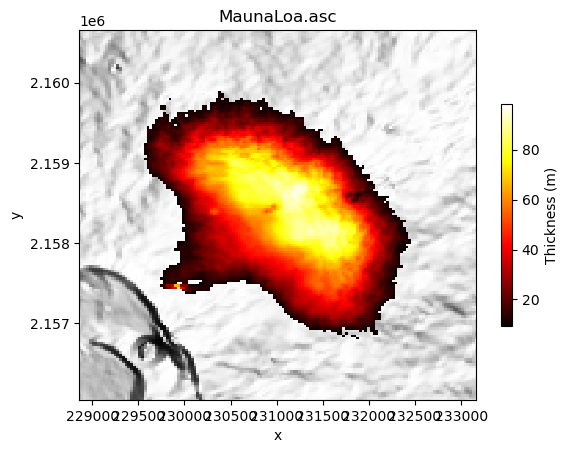

In [13]:
mll_outputs = sorted(glob.glob(f'mr_lava_loba/{name}*thickness_masked*.asc'))
mll_out = mll_outputs[-1]
victor.plot_flow(asc_name,mll_out)

### IMEX_Lava: Additional Notes

IMEX_Lava input parameters are stored in `IMEX_LavaFlow.inp` in the `IMEX` folder. This is a physics-based, highly accurate, slower model. If desiring to change additional input parameters, we recommend editing the `TEMPERATURE_PARAMETERS`, `RHEOLOGY_PARAMETERS`, `GAS_TRANSPORT_PARAMETERS`, and `LIQUID_TRANSPPORT_PARAMETERS` namelists as needed. All other sections are carefully prepared based in your initial basic inputs, so ignore all other sections.

In [14]:
os.chdir("/home/jovyan/Lava Benchmark/IMEX_LavaFlow")
h=open("IMEX_LavaFlow.inp","r+")
inp = h.readlines()
inp[1] = f''' RUN_NAME="{name}"\n'''
inp[4] = f""" T_END=  {run_time},\n"""
inp[5] = f""" DT_OUTPUT=  1000,\n"""
inp[13] = f""" X0= {int(xll)+res[0]}     ,\n"""
inp[14] = f""" Y0= {int(yll)+res[0]}     ,\n"""
inp[15] = f""" COMP_CELLS_X=  {int(len(array.x)/downscale)-5},\n"""
inp[16] = f""" COMP_CELLS_Y=  {int(len(array.y)/downscale)-5},\n"""
inp[17] = f""" CELL_SIZE = {res[0]*downscale}D0 ,\n"""
inp[103] = f"""  X_SOURCE=  {int(vent_easting)}.0D0 ,\n"""
inp[104] = f"""  Y_SOURCE=  {int(vent_northing)}.0D0 ,\n"""
inp[105] = f"""  R_SOURCE=  {res[0]}D0     ,\n"""
inp[106] = f""" VEL_SOURCE= {float(volume)/(res[0]**2*np.pi*run_time)} \n"""
h.seek(0)
h.writelines(inp)
h.truncate()
h.close()

if type_flag == 1:
    subprocess.run(f"""ln -s ../{asc_name} topography_dem.asc""",shell=True)
else:
    subprocess.run(f"""ln -s {dem} topography_dem.asc""",shell=True)
subprocess.run("./IMEX_LavaFlow",shell=True)
os.chdir("/home/jovyan/Lava Benchmark")

 ---------------------
 IMEX_LavaFlow 1.0
 ---------------------
 OpenMP program
 Number of threads used           4
 Run name: MaunaLoa                                
 ----- 2D SIMULATION -----
 Ambient density =    1.1763298740177413       (kg/m3)
 CARRIER PHASE: liquid
 Carrier phase kinematic viscosity:  -1.0000000000000000     
 radiative_term_coeff =    2.2680000000000002E-008
 convective_term_coeff =    35.000000000000000     
 Searching for DEM file
 Reading DEM file
 ncols        1804
 nrows        1690
 Percent Complete: 100.00% 
 IOSTAT=          -1
 thickness_levels          -1
 dyn_pres_levels          -1
 Searching for probes coords
 Source area =   2803.9551335989140       Error =   1.9329372192511407E-004
 Implicit equations =           3

 ******** START COMPUTATION *********

 WRITING MaunaLoa_0000.asc                       
 WRITING MaunaLoa_T_0000.asc                     
 WRITING MaunaLoa_T_surf_0000.asc                
 WRITING MaunaLoa_T_ground_0000.asc         

KeyboardInterrupt: 

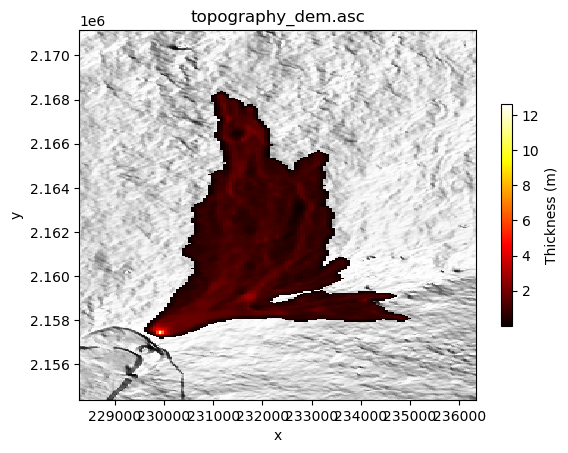

In [16]:
victor.plot_flow("topography_dem.asc", f"{name}_max.asc")

### LAVA2D: Additional Notes

LAVA2D input parameters are stored in `input.py` in the `lava2d` folder. This is a physics-based, highly accurate, slower model. If desiring to change additional input parameters, we recommend editing the `set_vent_props`, `set_lava_props`, `set_rheo`, `set_ambient`, and `set_numeric` sections as needed. All other sections are carefully prepared based in your initial basic inputs, so please leave them as is.

In [17]:
os.chdir("/home/jovyan/Lava Benchmark/lava2d")
left, bottom, right, top = r.bounds
lower_left = transformer.transform(left, bottom)
top_right = transformer.transform(right, top)
src = transformer.transform(vent_easting, vent_northing)

l = open("input.py","r+")
inp = l.readlines()

if type_flag == 0:
    inp[4] = f"""    path_to_dem_file    = ('/home/jovyan/shared-readwrite/DEMs/MaunaLoa.tif'),\n"""
else:
    inp[4] = f"""    path_to_dem_file    = ('/home/jovyan/shared-readwrite/DEMs/MaunaLoa.tif'),\n"""
inp[5] = f"""    Lon_SRC             = {src[1]}, # source longitude\n"""
inp[6] = f"""    Lat_SRC             = {src[0]},    # source latitude\n"""
inp[7] = f"""    Lon_LowerLeft       = {left}, # bounding box: lower-left longitude\n"""
inp[8] = f"""    Lat_LowerLeft       = {bottom}, # bounding box: lower-left latitude\n"""
inp[9] = f"""    Lon_UpperRight      = {right}, # bounding box: upper-right longitude\n"""
inp[10] = f"""    Lat_UpperRight      = {top},   # bounding box: upper-right latitude\n"""
inp[12] = f"""    dx_desired          = {res[0]*downscale},          # meters\n"""
inp[67] = f"""    max_iter = None, #one of them can be none, so the default value for both is none, if both none run till killed\n"""
inp[68] = f"""    max_time_hr = {run_time/3600},\n"""
l.seek(0)
l.writelines(inp)
l.truncate()
l.close()

k=open("./example_vents/vent_01.txt","r+")
inp = k.readlines()
inp[1] = f'''0	0	0	100	-75	20	{volume/(run_time*50)}\n'''
inp[2] = f'''10000	0	0	100	-75	20	{volume/(run_time*50)}\n'''

k.seek(0)
k.writelines(inp)
k.truncate()
k.close()

subprocess.run("python input.py",shell=True)

| --- Reading DEM Dataset --- |
| --- Building Modelling Subset --- |
| --- Building Coordinate Transform --- |
| --- Preparing DEM --- |
| --- DEM Preparation Complete --- |
| --- Initializing Model Domain --- |
| --- Beginning Model Evolution --- |
|  Step (sub): 10 (1)  |  dx: 79.64444546916893 m  |  Grid: 17 x 17  |  dt (type): 5.000 s (max)  |  t: 0.01 hr |
|  Step (sub): 20 (1)  |  dx: 79.64444546916893 m  |  Grid: 17 x 17  |  dt (type): 5.000 s (max)  |  t: 0.03 hr |
|  Step (sub): 30 (1)  |  dx: 79.64444546916893 m  |  Grid: 17 x 17  |  dt (type): 5.000 s (max)  |  t: 0.04 hr |
|  Step (sub): 40 (1)  |  dx: 79.64444546916893 m  |  Grid: 17 x 17  |  dt (type): 5.000 s (max)  |  t: 0.05 hr |
|  Step (sub): 50 (1)  |  dx: 79.64444546916893 m  |  Grid: 33 x 17  |  dt (type): 5.000 s (max)  |  t: 0.07 hr |
|  Step (sub): 60 (1)  |  dx: 79.64444546916893 m  |  Grid: 33 x 33  |  dt (type): 5.000 s (max)  |  t: 0.08 hr |
|  Step (sub): 70 (1)  |  dx: 79.64444546916893 m  |  Grid: 33 x 

CompletedProcess(args='python input.py', returncode=0)

In [19]:
data = xr.open_dataset("outputs/out.nc",group="DATA/PHYSICS",decode_coords="all")
data = data.where(data!=0, np.nan)

coord = xr.open_dataset("outputs/out.nc",group="DATA", decode_coords="all")
lat = coord.lat[:,0]
lon = coord.lon[0,:]
data['rows'] = lat.values
data['cols'] = lon.values

data = data.rename({"rows": "y", "cols": "x"})
repeated_arr_x = np.repeat(data.y.values[0], len(data.x))
repeated_arr_y = np.repeat(data.x.values[0], len(data.y))

utm1 = transformer2.transform(repeated_arr_x,data.x.values)
utm2 = transformer2.transform(data.y.values,repeated_arr_y)

data['x'] = utm1[0]
data['y'] = utm2[1]
data.lava_thickness_total.rio.to_raster(f"{name}_output.tiff")

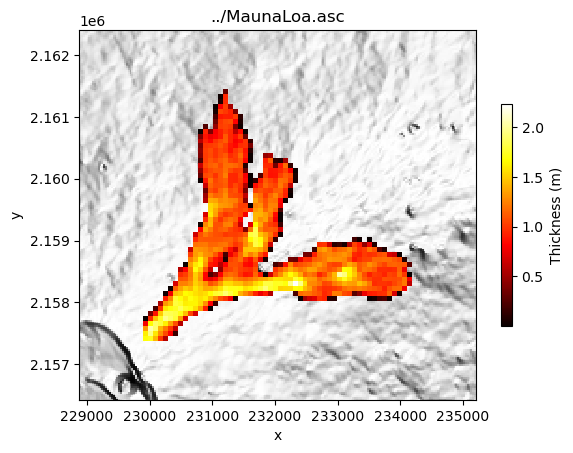

In [23]:
victor.plot_flow("../MaunaLoa.asc", f"{name}_output.tiff")

### Finally, we can take a look at all the models side by side.

In [24]:
os.chdir("/home/jovyan/Lava Benchmark/")

r = rxr.open_rasterio(f"IMEX_LavaFlow/{name}_max.asc",masked=True)
r2 = rxr.open_rasterio(f"Molasses/molasses_{name}.asc",masked=True)
r3 = rxr.open_rasterio(mll_out,masked=True)
r4 = rxr.open_rasterio(f"lava2d/{name}_output.tiff",masked=True)
r_min, r_max = r.min(), r.max()
r2_min, r2_max = r2.min(), r2.max()
r3_min, r3_max = r3.min(), r3.max()
r4_min, r4_max = r4.min(), r4.max()

maximum = np.max((r_max,r2_max,r3_max,r4_max))
idx_max = np.argmax((r_max,r2_max,r3_max,r4_max))

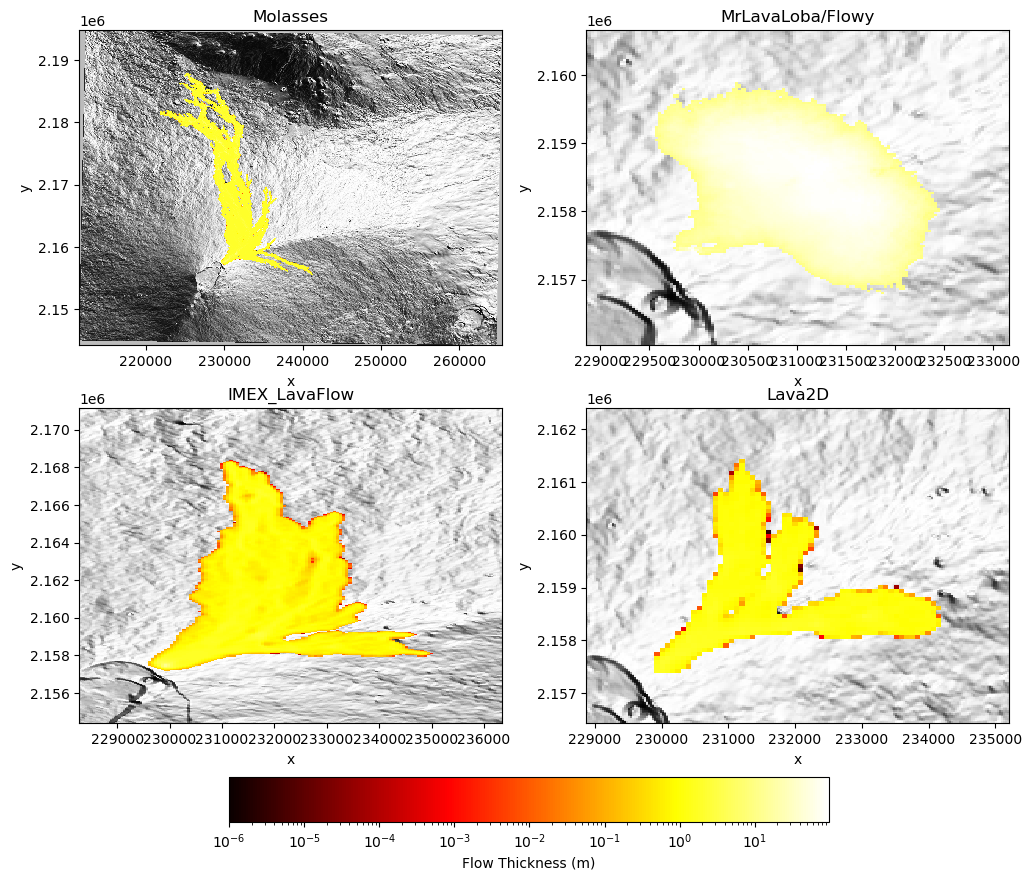

In [28]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(ncols=2, nrows=2, figsize = (12,9))

thickness0 = victor.plot_flow(asc_name, f"Molasses/molasses_{name}.asc", axes=ax0,zoom=False,title='Molasses',minimum=1e-6,scale=maximum)
thickness1 = victor.plot_flow(asc_name, mll_out, axes=ax1, title='MrLavaLoba/Flowy',minimum=1e-6, scale=maximum)
thickness2 = victor.plot_flow(asc_name, f"IMEX_LavaFlow/{name}_max.asc", axes=ax2,title='IMEX_LavaFlow', minimum=1e-6, scale=maximum)
thickness3 = victor.plot_flow(asc_name, f"lava2d/{name}_output.tiff", axes=ax3 ,title='Lava2D', minimum=1e-6, scale=maximum)

cbar_ax = fig.add_axes([.25, 0, 0.5, 0.05])
thickness = [thickness0, thickness1, thickness2, thickness3]
thickness = thickness[idx_max]
fig.colorbar(thickness, cax=cbar_ax, label="Flow Thickness (m)", orientation="horizontal")